In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report)
from imblearn.over_sampling import SMOTE
import pickle

df = pd.read_csv('../data/cleaned_dataset.csv')
print(df.shape)
df.head()

(118614, 18)


,employee_department,employee_campus,employee_position,employee_seniority_years,is_contractor,employee_classification,has_foreign_citizenship,has_criminal_record,total_printed_pages,num_printed_pages_off_hours,total_files_burned,burned_from_other,is_abroad,hostility_country_level,num_entries,num_unique_campus,entry_during_weekend,is_malicious
0,0,2,15,22,0,2,0,0,0,0,4,0,0,0,1,1,1,0
1,0,2,15,22,0,2,0,0,0,0,0,0,0,0,1,1,0,0
2,0,2,15,22,0,2,0,0,0,0,2,0,0,0,1,1,0,0
3,0,2,15,22,0,2,0,0,1,0,0,0,0,0,1,1,0,0
4,0,2,15,22,0,2,0,0,0,0,0,0,0,0,0,0,0,0


In [2]:
X = df.drop(columns=['is_malicious'])
y = df['is_malicious']

print("Features:", X.columns.tolist())
print("Class distribution:", y.value_counts().to_dict())

Features: ['employee_department', 'employee_campus', 'employee_position', 'employee_seniority_years', 'is_contractor', 'employee_classification', 'has_foreign_citizenship', 'has_criminal_record', 'total_printed_pages', 'num_printed_pages_off_hours', 'total_files_burned', 'burned_from_other', 'is_abroad', 'hostility_country_level', 'num_entries', 'num_unique_campus', 'entry_during_weekend']
Class distribution: {0: 112228, 1: 6386}


In [3]:
X_train_raw, X_test, y_train_raw, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train_raw, y_train_raw)

print("Before SMOTE:", y_train_raw.value_counts().to_dict())
print("After SMOTE:", pd.Series(y_train).value_counts().to_dict())

Before SMOTE: {0: 89782, 1: 5109}
After SMOTE: {0: 89782, 1: 89782}


In [4]:
# Decision Tree
dt = DecisionTreeClassifier(random_state=42, max_depth=10)
dt.fit(X_train, y_train)

# Random Forest
rf = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=10)
rf.fit(X_train, y_train)

print("Both models trained!")

Both models trained!


In [5]:
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
    print(f"F1-Score:  {f1_score(y_test, y_pred):.4f}")
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Normal', 'Malicious']))
    return y_pred

dt_preds = evaluate_model("Decision Tree", dt, X_test, y_test)
rf_preds = evaluate_model("Random Forest", rf, X_test, y_test)


  Decision Tree
Accuracy:  0.9072
Precision: 0.3391
Recall:    0.7627
F1-Score:  0.4695

Confusion Matrix:
[[20548  1898]
 [  303   974]]

Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      0.92      0.95     22446
   Malicious       0.34      0.76      0.47      1277

    accuracy                           0.91     23723
   macro avg       0.66      0.84      0.71     23723
weighted avg       0.95      0.91      0.92     23723


  Random Forest
Accuracy:  0.9498
Precision: 0.5226
Recall:    0.7800
F1-Score:  0.6258

Confusion Matrix:
[[21536   910]
 [  281   996]]

Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      0.96      0.97     22446
   Malicious       0.52      0.78      0.63      1277

    accuracy                           0.95     23723
   macro avg       0.75      0.87      0.80     23723
weighted avg       0.96      0.95      0.95     23723



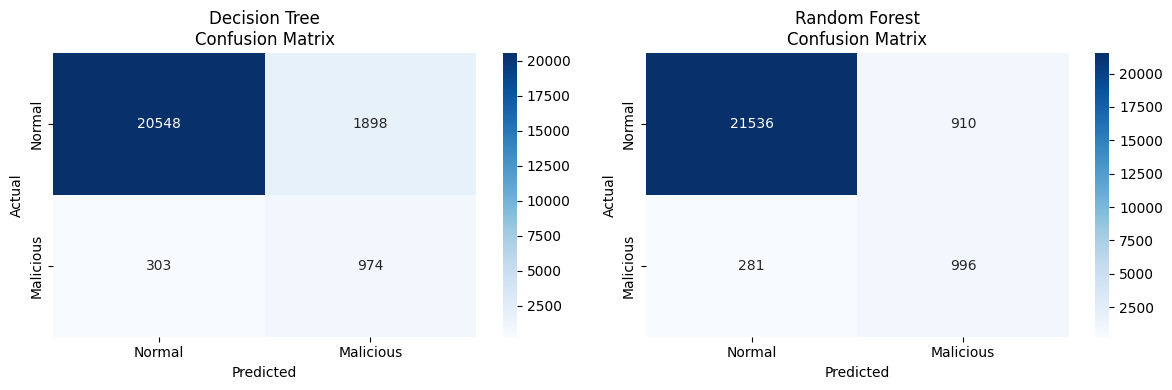

Saved!


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, model, preds, name in zip(axes, [dt, rf], [dt_preds, rf_preds], 
                                   ["Decision Tree", "Random Forest"]):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal','Malicious'],
                yticklabels=['Normal','Malicious'])
    ax.set_title(f'{name}\nConfusion Matrix')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('../models/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

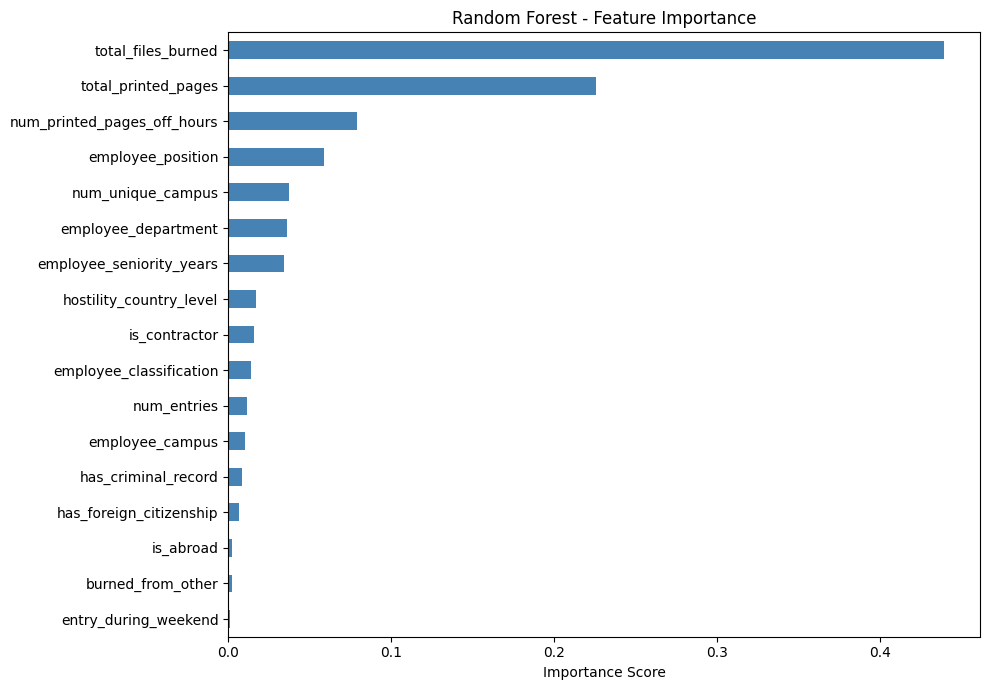

In [7]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(10, 7))
importances.plot(kind='barh', color='steelblue')
plt.title('Random Forest - Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../models/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# Save Random Forest 
with open('../models/rf_model.pkl', 'w+b') as f:
    pickle.dump(rf, f)

# Save feature names for the app
with open('../models/feature_names.pkl', 'w+b') as f:
    pickle.dump(X.columns.tolist(), f)

# Save test data for testing scenarios
X_test.to_csv('../data/X_test.csv', index=False)
y_test.to_csv('../data/y_test.csv', index=False)

print("Model and test data saved!")

Model and test data saved!
